In [5]:
#!pip install statsforecast
#!pip install mlforecast
#!pip install lightgbm

In [7]:
import pandas as pd
import numpy as np
import warnings
import plotly
from statsforecast import StatsForecast
from statsforecast.models import Naive, SeasonalNaive, AutoARIMA, ARIMA
from mlforecast import MLForecast
from lightgbm import LGBMRegressor

from utilsforecast.plotting import plot_series


df = pd.read_parquet('/work/sample_hotels-1.parquet')
df['ds'] = pd.to_datetime(df['ds'])
otb_cols = [f'otb_{i}' for i in range(28, 61) if f'otb_{i}' in df.columns]
df = df[['unique_id', 'ds', 'y', 'location_type', 'hotel_type',]+ otb_cols]

/root/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


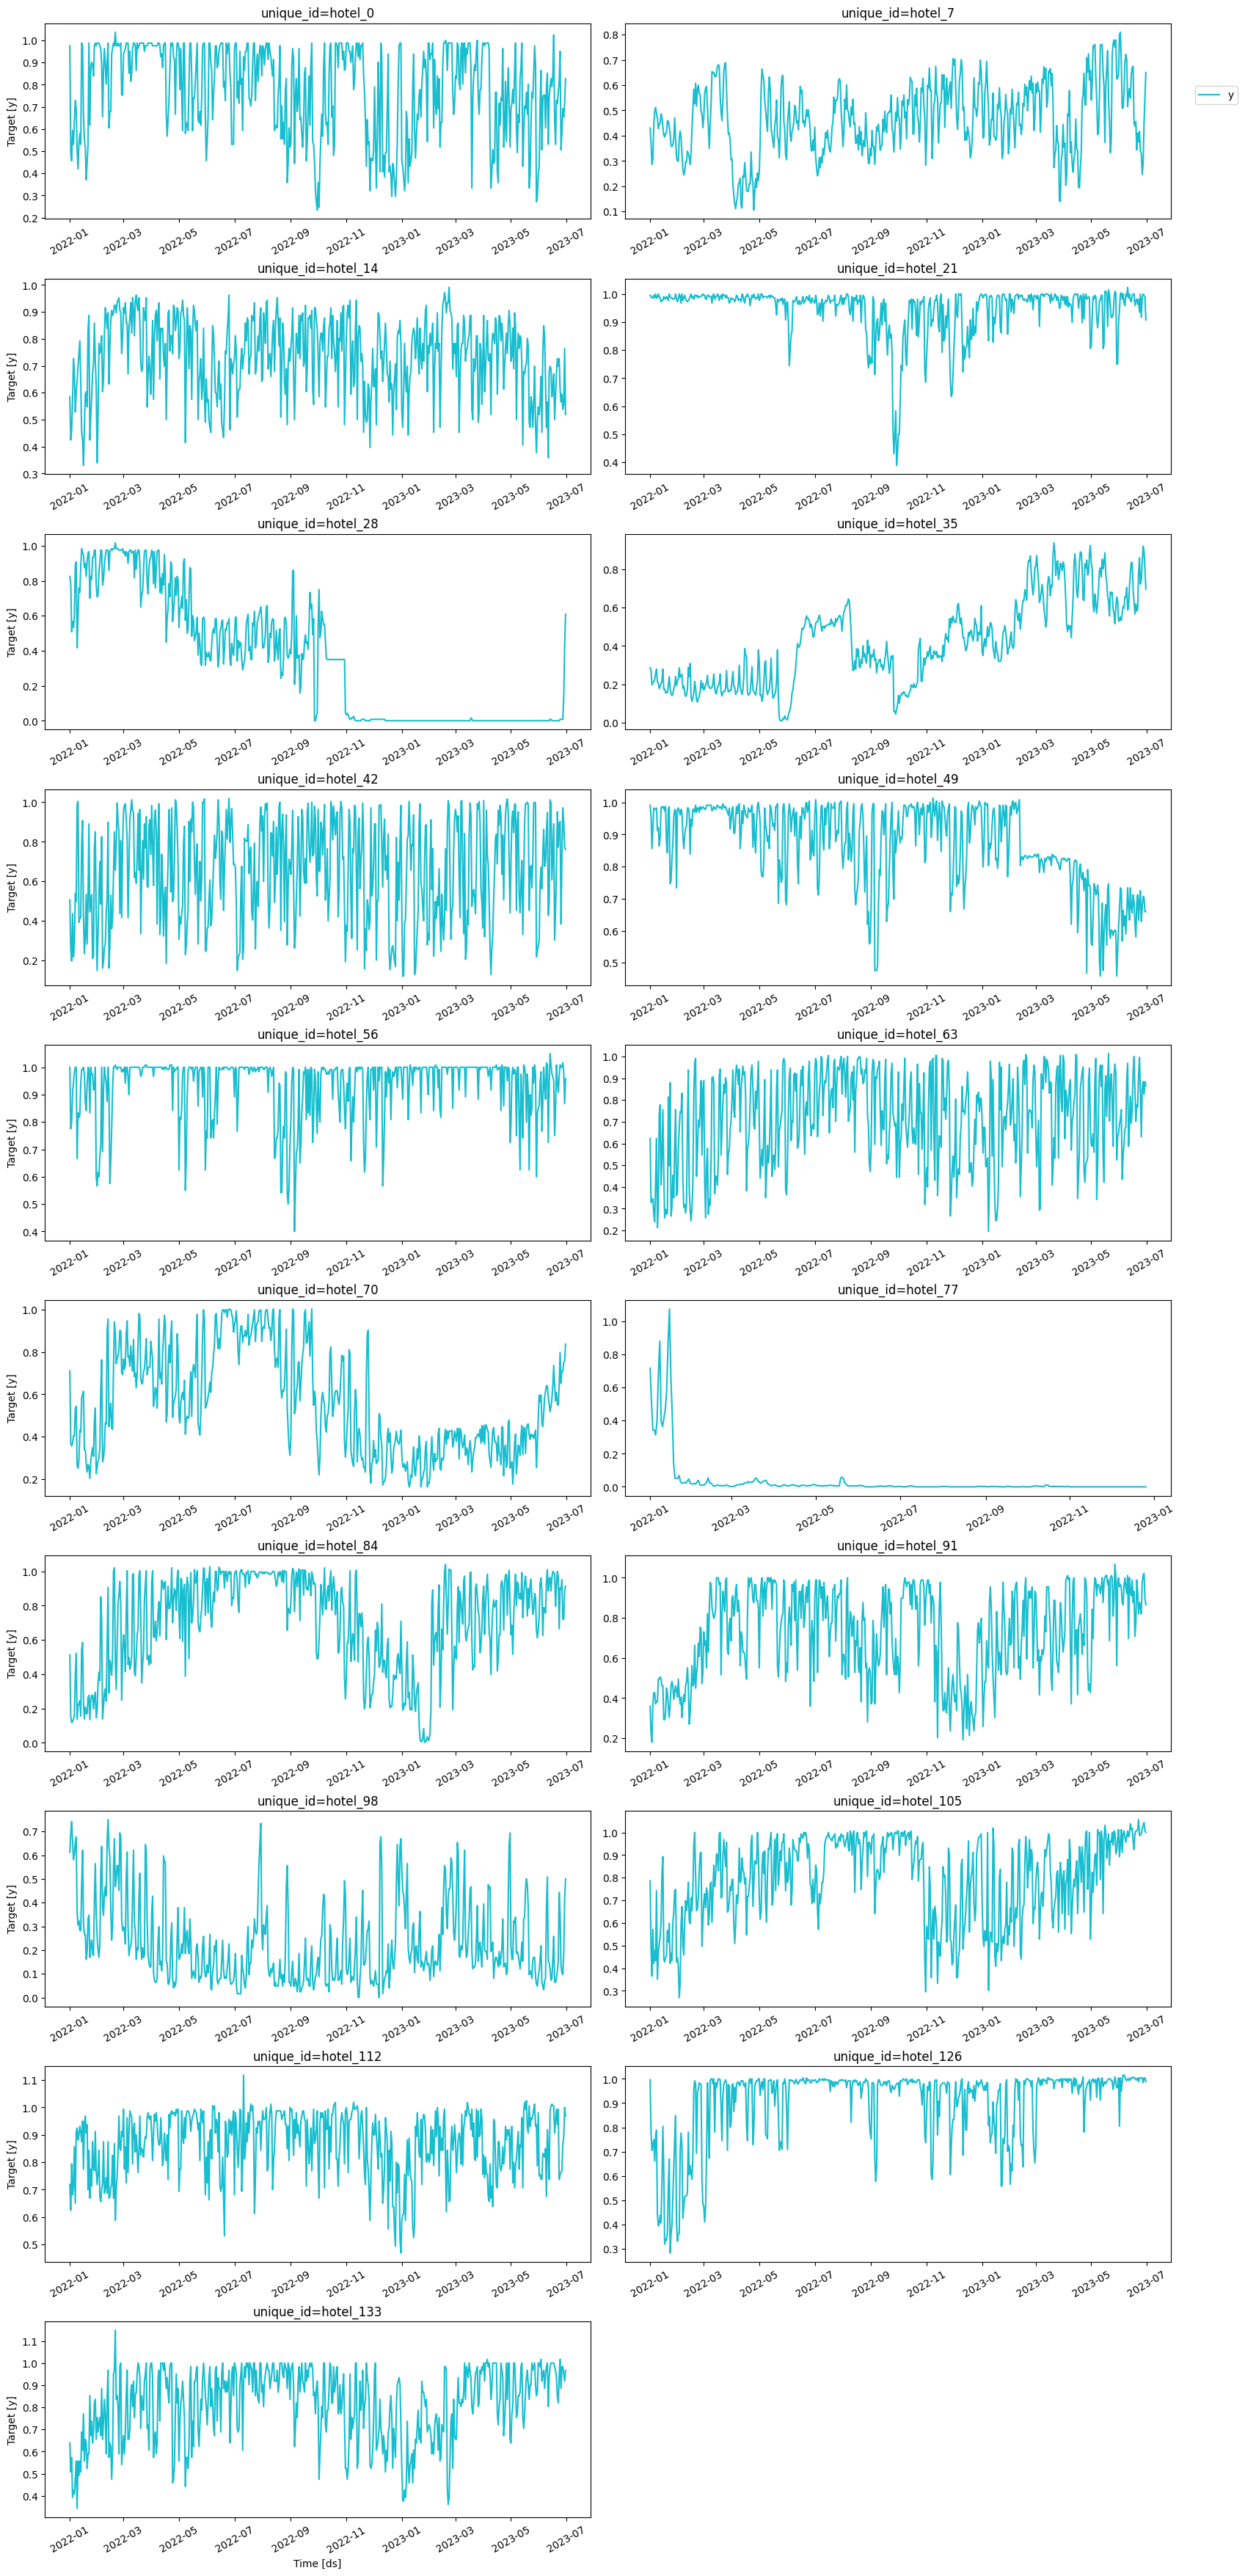

In [9]:

display(plot_series(df, max_ids=19))


In [11]:
df = df.query(
    "unique_id not in ['hotel_77', 'hotel_28']"
)

In [13]:
test_df = df.groupby('unique_id').tail(28).reset_index(drop=True)
train_df = df.groupby('unique_id').head(-28).reset_index(drop=True)

In [15]:
test_df.shape[0]/17

28.0

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=94252149-99d5-4a3a-8951-54d7f526c43a' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>